# **Building Linear Regression Model**

In [ ]:
# importing numpy library
import numpy as np

In [ ]:
class Linear_Regression():
                               #this cls is used to built a model object that can train (fit), update weights and can make predictions
  # initiating the parameters (learning rate & no. of iterations)
  def __init__(self, learning_rate, no_of_iterations):
    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  def fit(self, X, Y ):
    # number of training examples & number of features
    self.m, self.n = X.shape  # number of rows & columns

    # initiating the weight and bias
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    # implementing Gradient Descent
    for i in range(self.no_of_iterations):        #The model repeatedly updates weights to reduce prediction error.
      self.update_weights()

  def update_weights(self):                       #This function performs one step of gradient descent.
    Y_prediction = self.predict(self.X)           #   Y = Xw + b
    # calculate gradients
    dw = - (2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
    db = - 2 * np.sum(self.Y - Y_prediction)/self.m
    # upadating the weights
    self.w = self.w - self.learning_rate*dw
    self.b = self.b - self.learning_rate*db

  def predict(self, X):
    return X.dot(self.w) + self.b

**Steps done in gradiendt descent** :
      - Calculates the predicted values.
      - Computes the error between predicted and actual values.
      - Updates the weights and bias to reduce the error.

# **Implementation of LR**

In [ ]:
#Using Linear Regression model for Prediction

# importing the dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
#data pre-processing
url = "https://gist.githubusercontent.com/saikrishnapotluri/33ace369025ec4de0dfb9f22a0c5b09f/raw/salary_Data.csv"
salary_data = pd.read_csv(url)

It is Github gist repo file

A Gist is like a mini-repository designed for:

Short scripts
Code snippets
Notes or configs

Instead of creating a full project repo, you just paste your code and share it instantly.

In [ ]:
salary_data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
salary_data.shape
# salary_data.shape()
salary_data.isnull().sum()

,0
YearsExperience,0
Salary,0


In [ ]:
#splitting the feature and target
X = salary_data.iloc[:,:-1].values    # all columns except last
Y = salary_data.iloc[:,1].values      # 1st column
print(X)
print(Y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [ ]:
#splitting training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state = 2)

In [ ]:
#training the model
model = Linear_Regression(learning_rate = 0.02, no_of_iterations=1000)

model.fit(X_train, Y_train)

# printing the parameter values ( weights & bias)
print('weight = ', model.w[0])
print('bias = ', model.b)

weight =  9514.400999035135
bias =  23697.406507136307


y = 9514(x) + 23697

salary = 9514(experience) + 23697

Predict the salary value for test data

In [ ]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


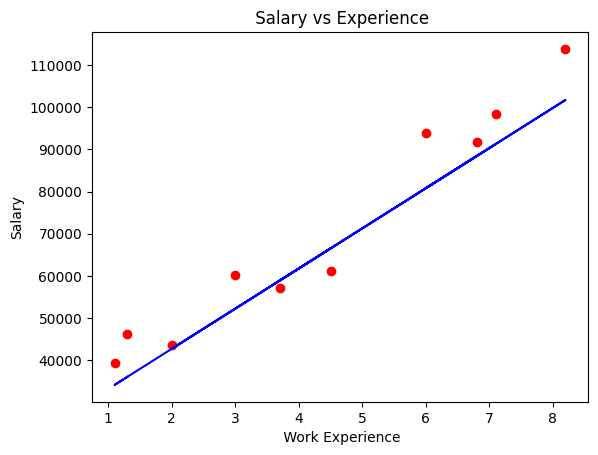

In [ ]:
#visualizing the predicted and actual values
plt.scatter(X_test, Y_test, color = 'red')
plt.plot(X_test, test_data_prediction, color='blue')
plt.xlabel(' Work Experience')
plt.ylabel('Salary')
plt.title(' Salary vs Experience')
plt.show()